In [9]:
# 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy import stats

In [10]:
import os

print("현재 작업 폴더:", os.getcwd())
print("현재 폴더 안 파일/폴더 목록:")
print(os.listdir())

현재 작업 폴더: c:\Users\jso25\OneDrive\Desktop\CICIDS\EDA
현재 폴더 안 파일/폴더 목록:
['first_EDA_trial.ipynb', 'second_EDA.ipynb']


In [11]:
import os

if os.path.exists("../data"):
    print("data 폴더 존재함")
    print(os.listdir("../data"))
else:
    print("data 폴더가 없음")

data 폴더 존재함
['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [12]:
# 데이터 파일 경로 설정
path = "../data/*.csv"

# 모든 csv 파일 불러오기
files = glob.glob(path)

df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

# 하나의 데이터프레임으로 합치기
df = pd.concat(df_list, ignore_index=True)

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [13]:
# 결측치 처리

df.isnull().sum().sort_values(ascending=False).head(20)

Flow Bytes/s                    1358
 Flow Duration                     0
 Destination Port                  0
 Total Backward Packets            0
Total Length of Fwd Packets        0
 Total Length of Bwd Packets       0
 Total Fwd Packets                 0
 Fwd Packet Length Max             0
 Fwd Packet Length Min             0
 Fwd Packet Length Std             0
 Fwd Packet Length Mean            0
Bwd Packet Length Max              0
 Bwd Packet Length Min             0
 Bwd Packet Length Mean            0
 Bwd Packet Length Std             0
 Flow Packets/s                    0
 Flow IAT Mean                     0
 Flow IAT Std                      0
 Flow IAT Max                      0
 Flow IAT Min                      0
dtype: int64

In [15]:
# Infinity → NaN 변환

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [16]:
# 결측치 제거

df.dropna(inplace=True)

In [17]:
# 이상치 처리

numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [19]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [20]:
# 칼럼명 공백 제거 및 확인
df.columns = df.columns.str.strip()

In [21]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [22]:
# 라벨 인코딩

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Label'] = le.fit_transform(df['Label'])

df['Label'].value_counts()

Label
0    310610
2      6116
4      4183
1      1456
5         1
3         1
Name: count, dtype: int64

In [23]:
# 피처 스케일링

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Label', axis=1)

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.221811,0.040571,-0.461615,0.177308,-0.199513,-0.182522,0.150699,0.180580,0.173108,-0.114149,...,-0.376858,-0.937957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.221811,-0.058282,-0.461615,0.177308,-0.199513,0.054132,0.150699,0.180580,0.173108,-0.114149,...,-0.376858,-0.937957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.824108,-0.604480,1.856468,-2.742579,-0.843146,-1.917981,0.853767,-2.607537,-1.789769,10.040862,...,-0.376858,0.843953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.221811,0.149080,1.856468,0.177308,2.329045,1.040188,0.853767,0.858771,0.865889,-0.114149,...,2.091426,-0.937957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.221811,-0.389547,-0.461615,0.177308,-0.337434,-0.931925,-0.083657,-0.045484,-0.057818,-0.114149,...,-0.376858,0.843953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 피처 엔지니어링

* Feature 1: Packet Ratio

    - Forward 패킷과 Backward 패킷의 비율을 나타내는 새로운 변수를 생성하였다.
    - 특정 공격에서는 패킷 흐름이 한 방향으로 치우치는 경향이 있기 때문에 유용한 특성이 될 수 있다.

In [24]:
df['Packet_Ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)

* Feature 2: Bytes per Packet
    - 패킷당 평균 바이트 크기를 나타내는 변수
    - 비정상 트래픽에서는 패킷 크기가 일정하거나 비정상적으로 작아질 수 있다.

In [25]:
df['Bytes_per_Packet'] = df['Total Length of Fwd Packets'] / (df['Total Fwd Packets'] + 1)

* Feature 3: Flow Speed
    - 초당 전송되는 바이트 수는 네트워크 공격 탐지에서 중요한 특징이 될 수 있다.

In [26]:
df['Flow_Bytes_per_Second'] = df['Flow Bytes/s']

* Feature 4: Packet Size Ratio
    - Forward와 Backward 패킷 크기 비율을 통해 트래픽 흐름의 비대칭성을 파악할 수 있다.

In [35]:
df["Packet_Size_Ratio"] = df["Total Length of Fwd Packets"] / (df["Total Length of Bwd Packets"] + 1)

## 최종 데이터 확인

In [27]:
df.shape

(322367, 82)

In [28]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Packet_Ratio,Bytes_per_Packet,Flow_Bytes_per_Second
71,53,71693,2,2,74,176,37,37,37.0,0.0,...,0,0,0.0,0.0,0,0,0,0.666667,24.666667,3487.090790
72,53,60738,2,2,74,200,37,37,37.0,0.0,...,0,0,0.0,0.0,0,0,0,0.666667,24.666667,4511.179163
78,443,208,4,0,46,0,46,0,11.5,23.0,...,0,0,0.0,0.0,0,0,0,4.000000,9.200000,221153.846200
88,53,83718,4,2,184,300,46,46,46.0,0.0,...,0,0,0.0,0.0,0,0,0,1.333333,36.800000,5781.313457
91,53,24027,2,2,68,100,34,34,34.0,0.0,...,0,0,0.0,0.0,0,0,0,0.666667,22.666667,6992.133849


In [29]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Packet_Ratio,Bytes_per_Packet,Flow_Bytes_per_Second
count,322367.000000,3.223670e+05,322367.000000,322367.000000,322367.000000,322367.000000,322367.000000,322367.000000,322367.000000,322367.000000,...,322367.0,322367.0,322367.0,322367.0,322367.0,322367.0,322367.000000,322367.000000,322367.000000,322367.000000
mean,74.381137,6.719689e+04,2.398273,1.878551,82.679421,194.510269,35.070891,34.603595,34.751126,0.258534,...,0.0,0.0,0.0,0.0,0.0,0.0,0.094389,0.953942,24.044674,23493.013592
std,96.393576,1.108209e+05,0.862784,0.684959,43.503121,101.414227,12.801060,13.270627,12.991149,2.264895,...,0.0,0.0,0.0,0.0,0.0,0.0,0.528409,0.760905,9.282209,60721.802129
min,1.000000,5.500000e+01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.000000
25%,53.000000,2.561600e+04,2.000000,2.000000,64.000000,138.000000,32.000000,31.000000,31.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.666667,21.333333,3757.935977
50%,53.000000,4.570100e+04,2.000000,2.000000,74.000000,198.000000,36.000000,36.000000,36.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.666667,24.666667,6431.684509
75%,53.000000,6.391750e+04,2.000000,2.000000,90.000000,256.000000,42.000000,42.000000,42.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.800000,28.666667,10498.837375
max,1028.000000,2.516910e+06,7.000000,6.000000,398.000000,904.000000,90.000000,90.000000,90.000000,49.074773,...,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,7.000000,72.000000,416464.891000


## 개인적으로 추가 확인

### 1️⃣ Class Imbalance 확인

: 데이터(CICIDS)는 공격 데이터 불균형 심함.

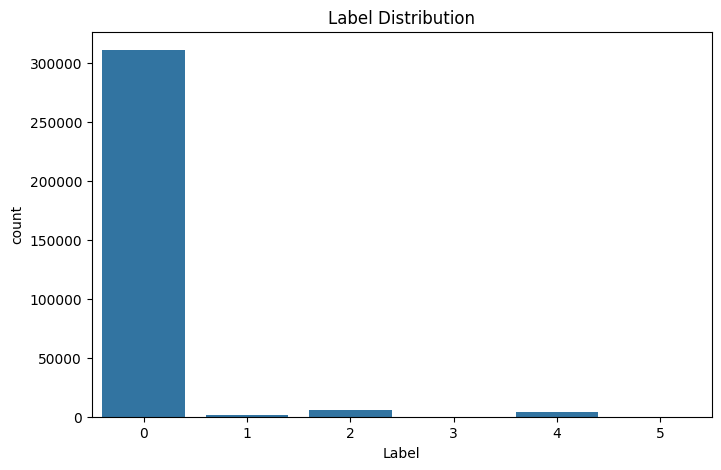

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=df['Label'])
plt.title("Label Distribution")
plt.show()

- 네트워크 공격 데이터는 정상 트래픽에 비해 특정 공격 유형이 매우 적게 존재하는 Class Imbalance 문제가 발생할 수 있다.
- 모델 학습 시 이러한 불균형은 성능 저하를 유발할 수 있으므로 분포를 확인하였다.

### 2️⃣ Correlation 기반 Feature Selection

: CICIDS 데이터는 컬럼이 70~80개라 너무 많음 -> 그래서 상관관계 확인하면 좋다.

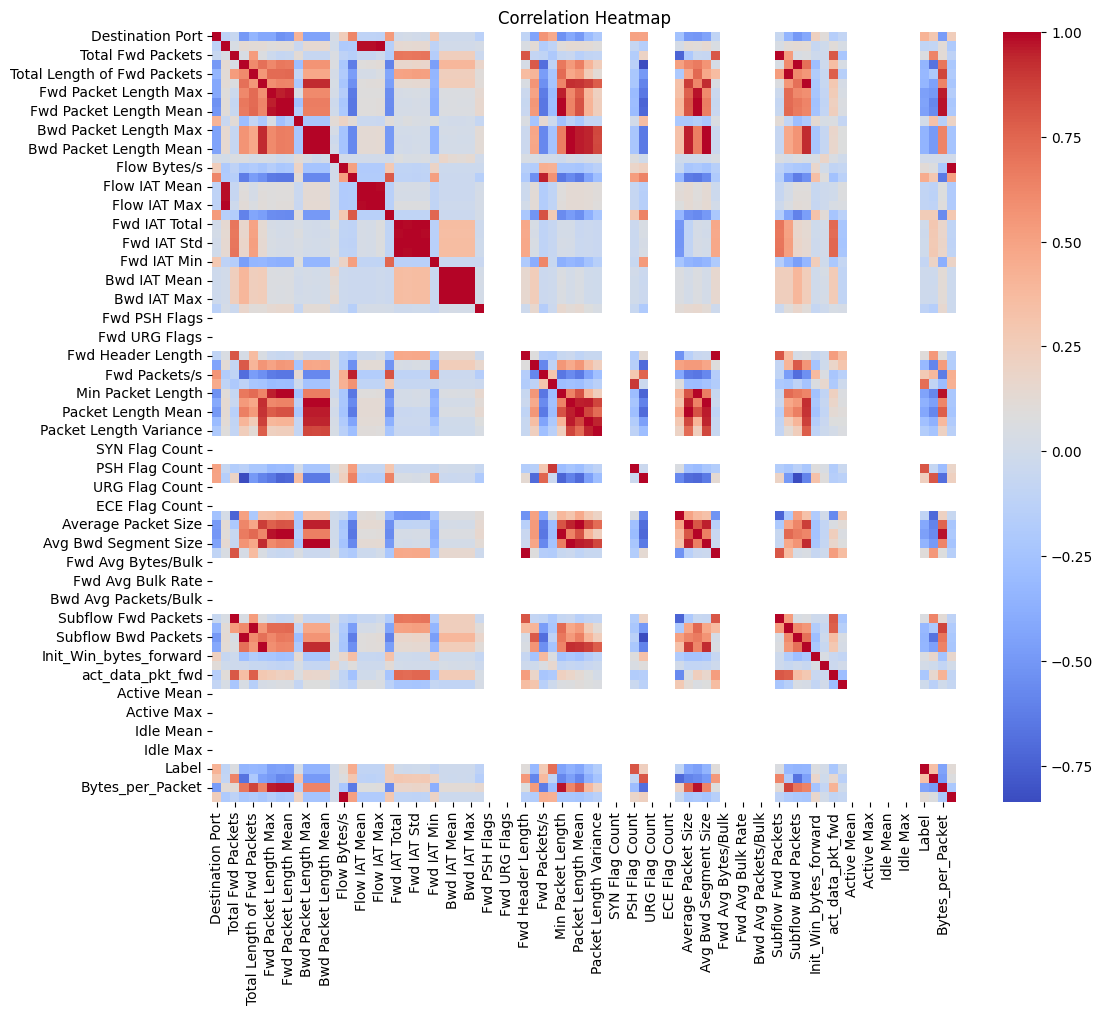

In [31]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- 변수 간 상관관계를 확인하여 서로 강하게 연관된 변수들을 파악하였다.
- 이는 향후 Feature Selection 및 모델 성능 개선에 활용할 수 있다.

### 3️⃣ High Correlation Feature 제거

In [32]:
threshold = 0.95
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]

df.drop(columns=drop_cols, inplace=True)

print("제거된 컬럼 수:", len(drop_cols))

제거된 컬럼 수: 28


- 높은 상관관계를 가진 변수는 중복 정보를 포함할 수 있으므로 다중공선성을 줄이기 위해 제거하였다.

### 4️⃣ Feature Importance 기반 Feature 확인 -> 모델 없이도 가능

In [33]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Label", axis=1)
y = df["Label"]

model = RandomForestClassifier(n_estimators=50)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Packet_Ratio                   0.129114
Fwd Header Length              0.121378
Total Length of Fwd Packets    0.083725
Total Fwd Packets              0.064464
Flow Packets/s                 0.058561
act_data_pkt_fwd               0.051380
PSH Flag Count                 0.050176
Fwd IAT Total                  0.050049
Init_Win_bytes_forward         0.044143
Fwd IAT Min                    0.042466
dtype: float64

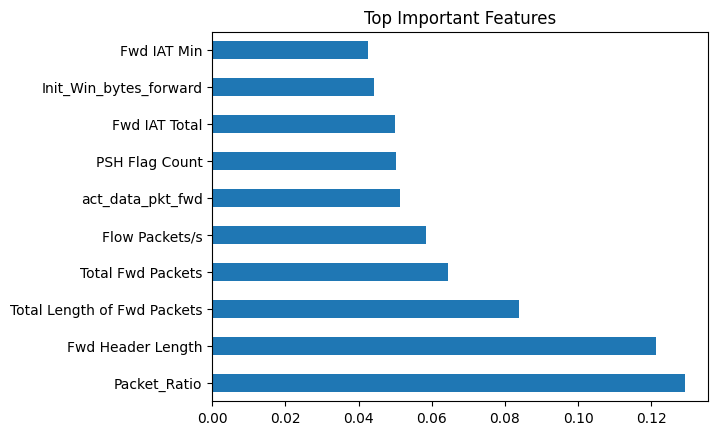

In [34]:
importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

- Random Forest 기반 feature importance를 활용하여 공격 탐지에 중요한 변수들을 확인하였다.

---

## 📌 추후 분석 목표 (Future Analysis Goals)

이번 단계에서는 데이터 전처리 및 피쳐 엔지니어링을 통해 머신러닝 분석을 위한 데이터셋을 정리하였다.  
EDA 과정에서 변수 간 관계와 데이터의 분포를 확인하였으며 결측치 및 이상치를 처리하고 분석에 활용할 수 있는 새로운 파생 변수를 생성하였다.

추후 분석에서는 다음과 같은 방향으로 데이터 분석을 확장하고자 한다.

### 1️⃣ 네트워크 공격 탐지 모델 구축
본 데이터셋은 네트워크 트래픽 정보를 기반으로 정상 트래픽과 다양한 공격 트래픽을 포함하고 있다.  
따라서 머신러닝 기반 분류 모델을 활용하여 **네트워크 공격을 탐지하는 모델을 구축하는 것을 목표로 한다.**

적용 가능한 모델 예시는 다음과 같다.

- Random Forest
- Gradient Boosting
- XGBoost
- Logistic Regression

이러한 모델을 통해 네트워크 트래픽 데이터를 기반으로 공격 여부를 예측하는 시스템을 구축할 수 있다.


### 2️⃣ Feature Importance 분석
모델 학습 이후에는 Feature Importance 분석을 수행하여  
**네트워크 공격 탐지에 중요한 변수들을 파악할 계획이다.**

이를 통해 다음과 같은 분석이 가능하다.

- 공격 탐지에 영향을 미치는 주요 네트워크 트래픽 변수 확인
- 불필요한 변수 제거를 통한 Feature Selection
- 모델 성능 개선


### 3️⃣ Class Imbalance 문제 분석
네트워크 공격 데이터는 일반적으로 정상 트래픽에 비해 공격 데이터의 비율이 낮거나 특정 공격 유형이 적게 존재하는 **Class Imbalance 문제**를 가질 수 있다.

따라서 추후 분석에서는 다음과 같은 방법을 고려할 예정이다.

- SMOTE 기반 데이터 증강
- UnderSampling / OverSampling
- 클래스 가중치 적용

이를 통해 모델이 소수 클래스에 대해서도 안정적으로 예측할 수 있도록 개선할 예정이다.


### 4️⃣ 모델 성능 평가
모델 학습 이후에는 다양한 평가 지표를 활용하여 모델 성능을 분석할 계획이다.

사용할 평가 지표는 다음과 같다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC Curve
- Confusion Matrix

특히 네트워크 보안 분야에서는 **False Negative (공격을 정상으로 판단하는 경우)**가 중요한 문제이므로  
Recall 지표를 중심으로 모델 성능을 평가할 예정이다.


### 5️⃣ 실제 네트워크 보안 환경 적용 가능성 탐색
최종적으로는 본 분석을 기반으로 실제 네트워크 환경에서 활용 가능한 **이상 트래픽 탐지 시스템**을 설계하는 것을 목표로 한다.

이를 통해 다음과 같은 활용 가능성을 기대할 수 있다.

- 실시간 네트워크 공격 탐지
- 보안 관제 시스템(SOC) 지원
- 침입 탐지 시스템(IDS) 개선